In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

best_model = joblib.load("../models/best_model.pkl")

In [2]:
y_pred = best_model.predict(X_test)

In [3]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(1674.5830231474013, np.float64(2250.111549890343), 0.4381024382882589)

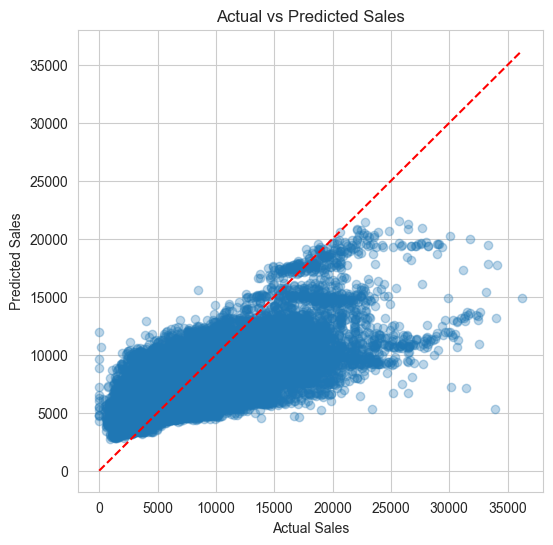

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

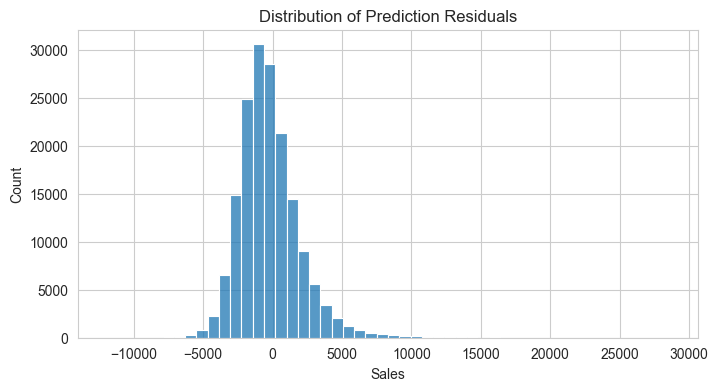

In [5]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=50)
plt.title("Distribution of Prediction Residuals")
plt.show()

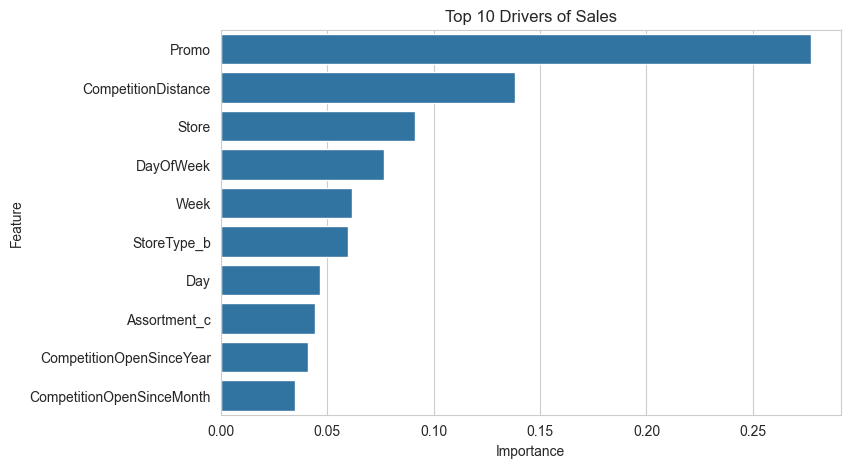

In [6]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Drivers of Sales")
plt.show()



In [7]:
##import numpy as np

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_value = mape(y_test, y_pred)
mape_value

np.float64(30.607664241763032)

## Key Business Insights

1. **Promotions are the strongest controllable driver of sales**, confirming their strategic importance.
2. **Store type and assortment influence baseline demand**, suggesting differentiated inventory strategies.
3. **Temporal features (week, month)** capture seasonality, enabling proactive demand planning.
4. Prediction errors increase at high sales volumes, indicating higher volatility during peak demand periods.

## Managerial Recommendations

- Use the model to **forecast sales at least one week ahead** to optimize staffing and inventory.
- Deploy promotions selectively in stores where uplift potential is highest.
- Treat high-sales periods as **risk zones** and add safety stock buffers.
- Continuously retrain the model as new sales data becomes available.

## Limitations and Future Work

- External factors such as weather and local events were not included.
- Advanced models such as XGBoost or LSTM could further improve performance.
- Store-level models may outperform a global model in certain regions.


The model achieves a Mean Absolute Percentage Error (MAPE) of approximately 30.60%, indicating strong predictive accuracy relative to actual sales.